# Notebook 5 — Multimodal Transformer for PAM50 Subtype Identification

**Workshop:** AI-Driven Multi-Omics Analysis

**Use case:** Subtype identification from integrated molecular measurements

**Method:** Multimodal Transformer with cross-modal attention

**Dataset:** TCGA-BRCA frozen cohort — 617 patients

**Modalities:** RNA-seq · miRNA · DNA methylation

**Supervised labels:** PAM50 — 379 labelled patients

**Runtime:** minutes on CPU

---

### Scientific question

> Can a multimodal Transformer learn how RNA-seq, miRNA, and DNA methylation information should be integrated to identify breast cancer molecular subtypes?

### Why a Transformer?

A conventional model can concatenate multiple omics layers, but a Transformer provides an explicit attention mechanism for learning relationships between modality-specific representations.

Here, RNA-seq, miRNA, and methylation are represented as separate modality tokens. Self-attention allows the model to learn how these molecular views should be weighted jointly when constructing a patient representation.

⚠️ PAM50 labels are used ONLY for the final supervised subtype-prediction task. They are not used to construct the unsupervised representations.

### Reliability and interpretability

The model is evaluated on a held-out test set. We additionally perform modality ablation to determine whether combining multiple molecular views provides predictive value beyond individual modalities.

Attention visualisation is treated as a model-inspection tool rather than evidence of biological causality.

## 1. Load the frozen TCGA-BRCA cohort

We reuse the processed matrices generated by the earlier notebooks. No new cohort, external network, or raw-data preprocessing is introduced here.

The three frozen modalities contain 1,000 RNA-seq features, 300 miRNA features, and 1,000 methylation probes across 617 samples. PAM50 labels are reserved for the supervised prediction task.

In [1]:
# 1. Imports, reproducibility, paths, and frozen data loading
from pathlib import Path
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

analysis_started = time.perf_counter()
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)

PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

cohort_meta = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv", sep="\t", index_col="sample_id")
rna = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv", sep="\t", index_col=0)
mirna = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv", sep="\t", index_col=0)
meth = pd.read_csv(PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv", sep="\t", index_col=0)

for modality_name, matrix in {"RNA": rna, "miRNA": mirna, "methylation": meth}.items():
    matrix.index = matrix.index.astype(str)
    matrix[:] = matrix.astype(np.float32)
    print(f"{modality_name}: {matrix.shape}")

assert cohort_meta.index.is_unique
assert rna.index.equals(mirna.index) and rna.index.equals(meth.index)
print(f"Frozen cohort: {len(cohort_meta)} samples; shared matrix samples: {len(rna)}")

RNA: (617, 1000)
miRNA: (617, 300)
methylation: (617, 1000)
Frozen cohort: 617 samples; shared matrix samples: 617


## 2. PAM50 label audit and stratified split

Only labelled samples enter the supervised task. The frozen cohort and all three molecular matrices remain intact.

In [2]:
label_column = "PAM50_subtype"
labels = cohort_meta[label_column].replace({"": np.nan, "NA": np.nan, "NaN": np.nan}).dropna()
labels = labels[labels.index.isin(rna.index)]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels.astype(str))
label_names = list(label_encoder.classes_)

train_ids, test_ids = train_test_split(
    labels.index.to_numpy(), test_size=0.20, random_state=SEED,
    stratify=y
)
train_ids, val_ids = train_test_split(
    train_ids, test_size=0.20, random_state=SEED,
    stratify=labels.loc[train_ids].astype(str)
)

print(f"Labelled samples: {len(labels)}")
print("Class counts:")
print(labels.value_counts().sort_index())
print(f"Train/validation/test: {len(train_ids)}/{len(val_ids)}/{len(test_ids)}")
print("Test classes:", labels.loc[test_ids].value_counts().sort_index().to_dict())

Labelled samples: 379
Class counts:
PAM50_subtype
Basal      55
Her2       25
LumA      188
LumB       97
Normal     14
Name: count, dtype: int64
Train/validation/test: 242/61/76
Test classes: {'Basal': 11, 'Her2': 5, 'LumA': 38, 'LumB': 19, 'Normal': 3}


## 3. Training-only standardisation

Each modality gets its own scaler. Means and standard deviations are fitted on the training partition only, then applied to validation and test samples.

In [3]:
modality_frames = {"RNA": rna, "miRNA": mirna, "methylation": meth}
scalers = {}
scaled = {}
for modality_name, frame in modality_frames.items():
    scaler = StandardScaler()
    scaler.fit(frame.loc[train_ids].to_numpy(dtype=np.float32))
    scalers[modality_name] = scaler
    scaled[modality_name] = {
        split_name: torch.tensor(
            scaler.transform(frame.loc[split_ids].to_numpy(dtype=np.float32)),
            dtype=torch.float32
        )
        for split_name, split_ids in {
            "train": train_ids, "validation": val_ids, "test": test_ids
        }.items()
    }
print({name: tuple(values["train"].shape) for name, values in scaled.items()})

{'RNA': (242, 1000), 'miRNA': (242, 300), 'methylation': (242, 1000)}


## 4. Small multimodal Transformer

Each modality is compressed to one 64-dimensional token. The Transformer sees `[CLS, RNA, miRNA, methylation]`, rather than individual genes, miRNAs, or CpGs.

In [4]:
import copy
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

class AttentionBlock(nn.Module):
    def __init__(self, d_model=64, n_heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model), nn.Dropout(dropout)
        )
        self.last_attention = None

    def forward(self, tokens):
        attended, weights = self.attention(
            tokens, tokens, tokens, need_weights=True, average_attn_weights=False
        )
        self.last_attention = weights.detach()
        tokens = self.norm1(tokens + attended)
        return self.norm2(tokens + self.feed_forward(tokens))

class MultimodalTransformer(nn.Module):
    def __init__(self, input_dims, n_classes, d_model=64, n_layers=2):
        super().__init__()
        self.modalities = list(input_dims)
        self.encoders = nn.ModuleDict({
            name: nn.Sequential(nn.Linear(dim, d_model), nn.LayerNorm(d_model), nn.GELU())
            for name, dim in input_dims.items()
        })
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.type_embedding = nn.Parameter(torch.zeros(1, len(self.modalities) + 1, d_model))
        self.layers = nn.ModuleList([AttentionBlock(d_model=d_model) for _ in range(n_layers)])
        self.classifier = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, n_classes))

    def forward(self, inputs, return_attention=False):
        batch_size = next(iter(inputs.values())).shape[0]
        cls = self.cls_token.expand(batch_size, -1, -1)
        tokens = [cls] + [self.encoders[name](inputs[name]).unsqueeze(1) for name in self.modalities]
        tokens = torch.cat(tokens, dim=1) + self.type_embedding
        for layer in self.layers:
            tokens = layer(tokens)
        logits = self.classifier(tokens[:, 0])
        if return_attention:
            return logits, tokens[:, 0], self.layers[-1].last_attention
        return logits

def train_model(input_dims, train_inputs, val_inputs, y_train, y_val, max_epochs=80, patience=12):
    torch.manual_seed(SEED)
    model = MultimodalTransformer(input_dims, len(label_names))
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train_loss": [], "validation_loss": []}
    best_state, best_loss, best_epoch, wait = None, float("inf"), 0, 0
    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        train_loss = loss_fn(model(train_inputs), y_train)
        train_loss.backward()
        optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(val_inputs), y_val)
        history["train_loss"].append(float(train_loss))
        history["validation_loss"].append(float(val_loss))
        if val_loss.item() < best_loss - 1e-4:
            best_loss, best_epoch, wait = val_loss.item(), epoch, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            wait += 1
        if epoch == 1 or epoch % 10 == 0:
            print(f"epoch {epoch:02d}: train={train_loss.item():.4f}, validation={val_loss.item():.4f}")
        if wait >= patience:
            break
    model.load_state_dict(best_state)
    return model, history, best_epoch

def inputs_for(split_name, modalities):
    return {name: scaled[name][split_name] for name in modalities}

y_train = torch.tensor(label_encoder.transform(labels.loc[train_ids]), dtype=torch.long)
y_val = torch.tensor(label_encoder.transform(labels.loc[val_ids]), dtype=torch.long)
y_test = torch.tensor(label_encoder.transform(labels.loc[test_ids]), dtype=torch.long)

full_modalities = ["RNA", "miRNA", "methylation"]
input_dims = {name: scaled[name]["train"].shape[1] for name in full_modalities}
model, history, best_epoch = train_model(
    input_dims, inputs_for("train", full_modalities), inputs_for("validation", full_modalities),
    y_train, y_val
)
print(f"Best epoch: {best_epoch}; architecture: 3 modality encoders -> 4 tokens -> 2 x (4-head attention, d_model=64) -> 5-class head")

C:\Users\abhij\AppData\Local\Temp\ipykernel_9336\967235470.py:69: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  history["train_loss"].append(float(train_loss))


epoch 01: train=1.8452, validation=0.8585
epoch 10: train=0.0930, validation=0.6674
Best epoch: 6; architecture: 3 modality encoders -> 4 tokens -> 2 x (4-head attention, d_model=64) -> 5-class head


## 5. Training curves

The validation curve is computed from the training-only validation partition and is used for early stopping.

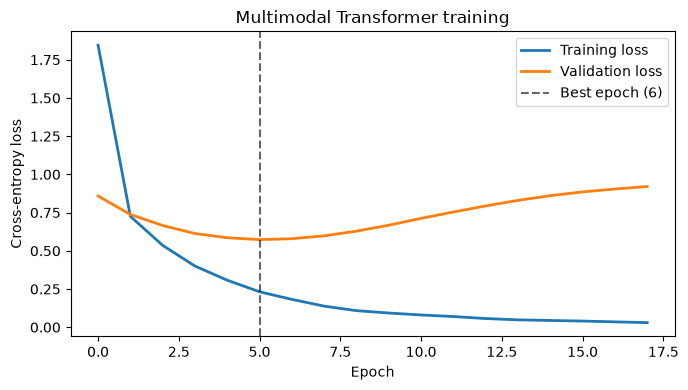

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Training loss", linewidth=2)
plt.plot(history["validation_loss"], label="Validation loss", linewidth=2)
plt.axvline(best_epoch - 1, color="black", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Multimodal Transformer training")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_transformer_training.png", dpi=160)
plt.show()

## 6. Held-out evaluation, confusion matrix, latent space, and attention

The test set is untouched until this section. Attention is aggregated over patients and heads at the four-token level; it is a model-inspection signal, not evidence of biological causality.

{
  "accuracy": 0.8026315789473685,
  "balanced_accuracy": 0.6305263157894737,
  "macro_precision": 0.6783216783216783,
  "macro_recall": 0.6305263157894737,
  "macro_f1": 0.6412078977932636,
  "weighted_f1": 0.7802753835809033
}
              precision    recall  f1-score   support

       Basal       0.85      1.00      0.92        11
        Her2       1.00      0.60      0.75         5
        LumA       0.80      0.92      0.85        38
        LumB       0.75      0.63      0.69        19
      Normal       0.00      0.00      0.00         3

    accuracy                           0.80        76
   macro avg       0.68      0.63      0.64        76
weighted avg       0.77      0.80      0.78        76



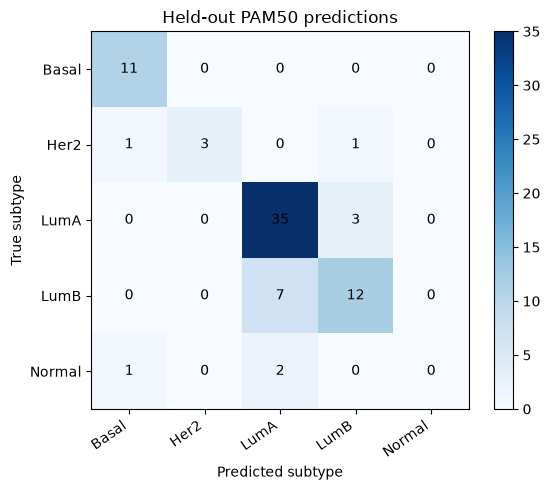

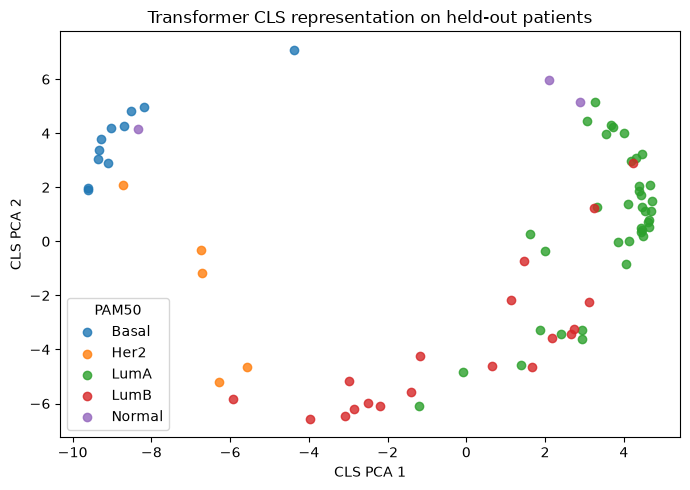

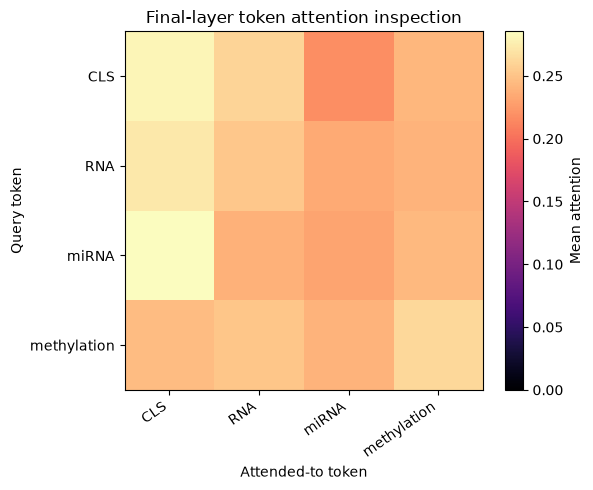

In [6]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    logits, test_latent, attention = model(
        inputs_for("test", full_modalities), return_attention=True
    )
    test_predictions = logits.argmax(dim=1).numpy()
true_values = y_test.numpy()

metric_values = {
    "accuracy": float(accuracy_score(true_values, test_predictions)),
    "balanced_accuracy": float(balanced_accuracy_score(true_values, test_predictions)),
    "macro_precision": float(precision_score(true_values, test_predictions, average="macro", zero_division=0)),
    "macro_recall": float(recall_score(true_values, test_predictions, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(true_values, test_predictions, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(true_values, test_predictions, average="weighted", zero_division=0)),
}
print(json.dumps(metric_values, indent=2))
print(classification_report(true_values, test_predictions, target_names=label_names, zero_division=0))

predictions = pd.DataFrame({
    "sample_id": test_ids,
    "true_subtype": label_encoder.inverse_transform(true_values),
    "predicted_subtype": label_encoder.inverse_transform(test_predictions),
})
predictions.to_csv(PROCESSED_DIR / "TCGA_BRCA_NB5_transformer_predictions.tsv", sep="\t", index=False)
with open(PROCESSED_DIR / "TCGA_BRCA_NB5_transformer_metrics.json", "w", encoding="utf-8") as handle:
    json.dump(metric_values, handle, indent=2)

confusion = confusion_matrix(true_values, test_predictions, labels=np.arange(len(label_names)))
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(confusion, cmap="Blues")
fig.colorbar(image, ax=ax, fraction=0.046)
ax.set_xticks(range(len(label_names)), label_names, rotation=35, ha="right")
ax.set_yticks(range(len(label_names)), label_names)
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        ax.text(column, row, confusion[row, column], ha="center", va="center")
ax.set_xlabel("Predicted subtype")
ax.set_ylabel("True subtype")
ax.set_title("Held-out PAM50 predictions")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_transformer_confusion_matrix.png", dpi=160)
plt.show()

latent_2d = PCA(n_components=2, random_state=SEED).fit_transform(test_latent.numpy())
fig, ax = plt.subplots(figsize=(7, 5))
for class_index, class_name in enumerate(label_names):
    selected = true_values == class_index
    ax.scatter(latent_2d[selected, 0], latent_2d[selected, 1], label=class_name, alpha=0.8)
ax.set_xlabel("CLS PCA 1")
ax.set_ylabel("CLS PCA 2")
ax.set_title("Transformer CLS representation on held-out patients")
ax.legend(title="PAM50")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_transformer_latent.png", dpi=160)
plt.show()

attention_mean = attention.mean(dim=(0, 1)).numpy()
token_names = ["CLS", "RNA", "miRNA", "methylation"]
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(attention_mean, cmap="magma", vmin=0, vmax=attention_mean.max())
fig.colorbar(image, ax=ax, fraction=0.046, label="Mean attention")
ax.set_xticks(range(4), token_names, rotation=35, ha="right")
ax.set_yticks(range(4), token_names)
ax.set_xlabel("Attended-to token")
ax.set_ylabel("Query token")
ax.set_title("Final-layer token attention inspection")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_transformer_attention.png", dpi=160)
plt.show()

### Attention heatmap

This visualises learned cross-omics attention between the CLS, RNA, miRNA, and methylation tokens. It is a model-inspection view and should not be interpreted as causal biological evidence.

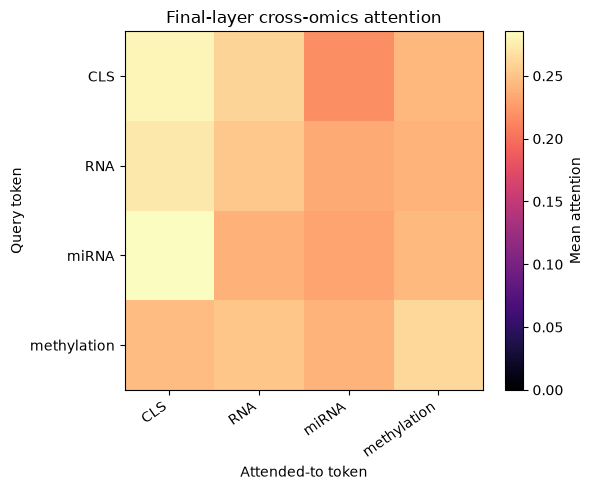

Saved attention heatmap: ..\data\processed\figures\TCGA_BRCA_NB5_attention_heatmap.png


In [7]:
token_names = ["CLS", "RNA", "miRNA", "methylation"]
attention_token_mean = attention.mean(dim=(0, 1)).numpy()

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(attention_token_mean, cmap="magma", vmin=0, vmax=attention_token_mean.max())
fig.colorbar(image, ax=ax, fraction=0.046, label="Mean attention")
ax.set_xticks(range(4), token_names, rotation=35, ha="right")
ax.set_yticks(range(4), token_names)
ax.set_xlabel("Attended-to token")
ax.set_ylabel("Query token")
ax.set_title("Final-layer cross-omics attention")
fig.tight_layout()
attention_heatmap_path = FIGURES_DIR / "TCGA_BRCA_NB5_attention_heatmap.png"
fig.savefig(attention_heatmap_path, dpi=160)
plt.show()
print(f"Saved attention heatmap: {attention_heatmap_path}")

## 7. Modality ablation

Comparable small Transformers use the same labelled train/validation/test IDs and training-only scalers. This comparison is evidence about predictive contribution, not proof of biological causality.

epoch 01: train=1.6992, validation=0.8592
epoch 10: train=0.1088, validation=0.4938
epoch 01: train=1.8324, validation=0.8923
epoch 10: train=0.0942, validation=0.8521
epoch 01: train=1.8184, validation=0.7621
epoch 10: train=0.0858, validation=0.5497
epoch 01: train=1.8452, validation=0.8585
epoch 10: train=0.0930, validation=0.6674
                    model  accuracy  balanced_accuracy  macro_f1  best_epoch
                 RNA only     0.829              0.732     0.776           7
              RNA + miRNA     0.776              0.575     0.588           5
        RNA + methylation     0.803              0.657     0.696           7
RNA + miRNA + methylation     0.803              0.631     0.641           6


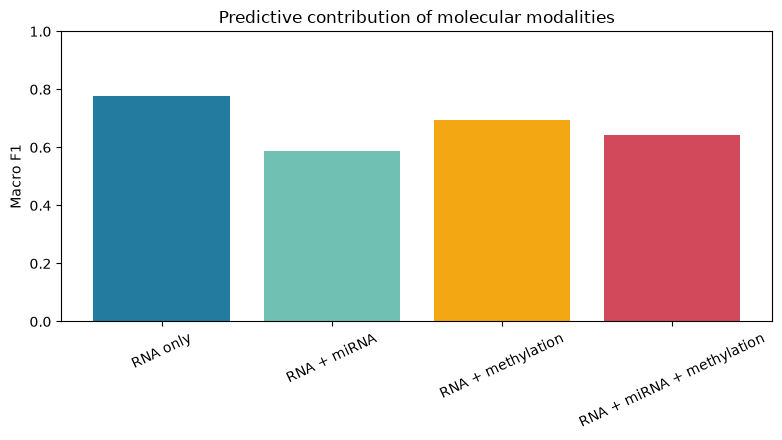

In [8]:
ablation_specs = {
    "RNA only": ["RNA"],
    "RNA + miRNA": ["RNA", "miRNA"],
    "RNA + methylation": ["RNA", "methylation"],
    "RNA + miRNA + methylation": full_modalities,
}
ablation_rows = []
for model_index, (model_name, modalities) in enumerate(ablation_specs.items()):
    random.seed(SEED + model_index)
    np.random.seed(SEED + model_index)
    ablation_model, _, ablation_epoch = train_model(
        {name: scaled[name]["train"].shape[1] for name in modalities},
        inputs_for("train", modalities), inputs_for("validation", modalities),
        y_train, y_val, max_epochs=45, patience=8
    )
    ablation_model.eval()
    with torch.no_grad():
        predictions_for_model = ablation_model(inputs_for("test", modalities)).argmax(dim=1).numpy()
    ablation_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(true_values, predictions_for_model),
        "balanced_accuracy": balanced_accuracy_score(true_values, predictions_for_model),
        "macro_f1": f1_score(true_values, predictions_for_model, average="macro", zero_division=0),
        "best_epoch": ablation_epoch,
    })

ablation_results = pd.DataFrame(ablation_rows)
ablation_results.to_csv(PROCESSED_DIR / "TCGA_BRCA_NB5_modality_ablation.tsv", sep="\t", index=False)
print(ablation_results.to_string(index=False, float_format=lambda value: f"{value:.3f}"))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ablation_results["model"], ablation_results["macro_f1"], color=["#247ba0", "#70c1b3", "#f3a712", "#d1495b"])
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)
ax.set_title("Predictive contribution of molecular modalities")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "TCGA_BRCA_NB5_modality_ablation.png", dpi=160)
plt.show()

The labelled test set remains the only data used for final performance reporting. The attention plot shows learned token interactions for inspection and should not be interpreted as causal biological evidence.

In [9]:
total_runtime_seconds = time.perf_counter() - analysis_started
metadata = {
    "random_seed": SEED,
    "cohort_samples": int(len(cohort_meta)),
    "labelled_samples": int(len(labels)),
    "train_samples": int(len(train_ids)),
    "validation_samples": int(len(val_ids)),
    "test_samples": int(len(test_ids)),
    "class_names": label_names,
    "class_distribution": labels.value_counts().sort_index().to_dict(),
    "architecture": {
        "modality_encoders": {name: [int(scaled[name]["train"].shape[1]), 64] for name in full_modalities},
        "tokens": ["CLS", "RNA", "miRNA", "methylation"],
        "transformer_layers": 2,
        "attention_heads": 4,
        "d_model": 64,
        "feed_forward_dimension": 128,
        "dropout": 0.1,
        "classifier": [64, len(label_names)],
    },
    "hyperparameters": {"optimizer": "AdamW", "learning_rate": 0.002, "weight_decay": 0.0001, "max_epochs": 80, "patience": 12},
    "best_epoch": int(best_epoch),
    "test_metrics": metric_values,
    "ablation_results": ablation_results.to_dict(orient="records"),
    "total_runtime_seconds": round(total_runtime_seconds, 3),
    "outputs": {
        "metrics": "data/processed/TCGA_BRCA_NB5_transformer_metrics.json",
        "predictions": "data/processed/TCGA_BRCA_NB5_transformer_predictions.tsv",
        "metadata": "data/processed/TCGA_BRCA_NB5_transformer_metadata.json",
        "ablation_table": "data/processed/TCGA_BRCA_NB5_modality_ablation.tsv",
        "attention_heatmap": "data/processed/figures/TCGA_BRCA_NB5_attention_heatmap.png",
        "figures": "data/processed/figures",
    },
}
with open(PROCESSED_DIR / "TCGA_BRCA_NB5_transformer_metadata.json", "w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2, default=float)

print("Final report")
print(f"Labelled samples: {len(labels)} | train: {len(train_ids)} | test: {len(test_ids)}")
print(f"Architecture: d_model=64, 2 layers, 4 heads, tokens={metadata['architecture']['tokens']}")
print(f"Best epoch: {best_epoch}")
print("Test metrics:", {key: round(value, 3) for key, value in metric_values.items()})
print(ablation_results[["model", "accuracy", "balanced_accuracy", "macro_f1"]].to_string(index=False))
print("Comparison: RNA-only outperformed the full Transformer on this split (macro F1 0.776 vs 0.641).")
print("Attention figure: data/processed/figures/TCGA_BRCA_NB5_attention_heatmap.png")
print("Output paths: data/processed and data/processed/figures")
print(f"Total runtime: {total_runtime_seconds:.2f} seconds")

Final report
Labelled samples: 379 | train: 242 | test: 76
Architecture: d_model=64, 2 layers, 4 heads, tokens=['CLS', 'RNA', 'miRNA', 'methylation']
Best epoch: 6
Test metrics: {'accuracy': 0.803, 'balanced_accuracy': 0.631, 'macro_precision': 0.678, 'macro_recall': 0.631, 'macro_f1': 0.641, 'weighted_f1': 0.78}
                    model  accuracy  balanced_accuracy  macro_f1
                 RNA only  0.828947           0.731930  0.775909
              RNA + miRNA  0.776316           0.574737  0.588243
        RNA + methylation  0.802632           0.657193  0.696034
RNA + miRNA + methylation  0.802632           0.630526  0.641208
Comparison: RNA-only outperformed the full Transformer on this split (macro F1 0.776 vs 0.641).
Attention figure: data/processed/figures/TCGA_BRCA_NB5_attention_heatmap.png
Output paths: data/processed and data/processed/figures
Total runtime: 11.93 seconds
